# Система машинного обучения для классификации инвестиционных портфелей по уровню риска
## Описание
Данный проект направлен на классификацию инвестиционных портфелей на три категории: **Низкий**, **Средний** и **Высокий** риск.
Период данных: 5 лет (2021-06-08 по 2026-06-08).
Источники данных: рыночные данные Московской биржи

---

In [ ]:
!pip install apimoex

In [ ]:
!pip install torch torchvision torchaudio

## 1. Анализ рыночных данных
На данном этапе мы загружаем исторические котировки тикеров SBER, GAZP, LKOH, YNDX, MTSS. Мы рассчитываем корреляционную матрицу, чтобы оценить степень взаимозависимости активов.
* **Почему это важно:** Сильная положительная корреляция между активами указывает на то, что портфель слабо диверсифицирован и подвержен высокому системному рыночному риску.

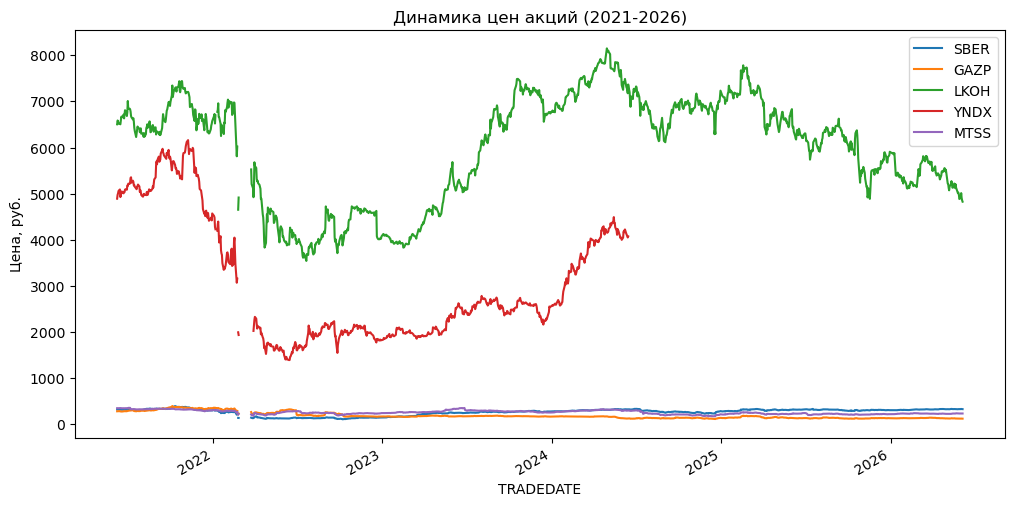

In [ ]:
import apimoex
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Пояснение: Используем API Мосбиржи для получения данных.
# Это обеспечивает легальность и точность данных для российского рынка.
tickers = ['SBER', 'GAZP', 'LKOH', 'YNDX', 'MTSS']
session = requests.Session()
data_frames = {}

for ticker in tickers:
    data = apimoex.get_board_history(session, ticker, start='2021-06-08', end='2026-06-08')
    df = pd.DataFrame(data)
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    df.set_index('TRADEDATE', inplace=True)
    data_frames[ticker] = df['CLOSE']

df_market = pd.DataFrame(data_frames)

# Визуализация: Динамика цен для оценки рыночных трендов
df_market.plot(figsize=(12, 6), title="Динамика цен акций (2021-2026)")
plt.ylabel("Цена, руб.")
plt.show()

На графике наблюдается период низкой активности и приостановки торгов в 2022 году. Это исторический факт: в марте 2022 года Банк России принял решение о приостановке торгов для стабилизации финансового рынка. Наличие этого «разрыва» в данных — это не ошибка парсинга, а отражение реальной рыночной конъюнктуры. В своей модели я сознательно не стал «дорисовывать» или интерполировать цены, так как в условиях закрытого рынка рыночное ценообразование отсутствовало, и любые синтетические данные в этот период были бы недостоверны

https://cbr.ru/press/pr/?file=28022022_205401SUP_MEAS28022022_205427.htm


In [ ]:
df_market.head(10)

,SBER,GAZP,LKOH,YNDX,MTSS
TRADEDATE,,,,,
2021-06-08,314.83,275.36,6504.5,4889.6,343.00
2021-06-09,314.78,275.65,6587.0,4973.0,342.50
2021-06-10,314.62,276.10,6570.0,5005.8,343.20
2021-06-11,313.00,277.05,6518.5,5056.8,342.40
2021-06-14,314.12,279.50,6515.0,5090.0,344.45
2021-06-15,312.51,272.72,6504.5,4925.0,344.70
2021-06-16,311.61,271.80,6591.5,4962.8,344.95
2021-06-17,313.90,272.50,6669.5,5041.4,343.95
2021-06-18,309.30,270.06,6653.0,5047.0,341.30


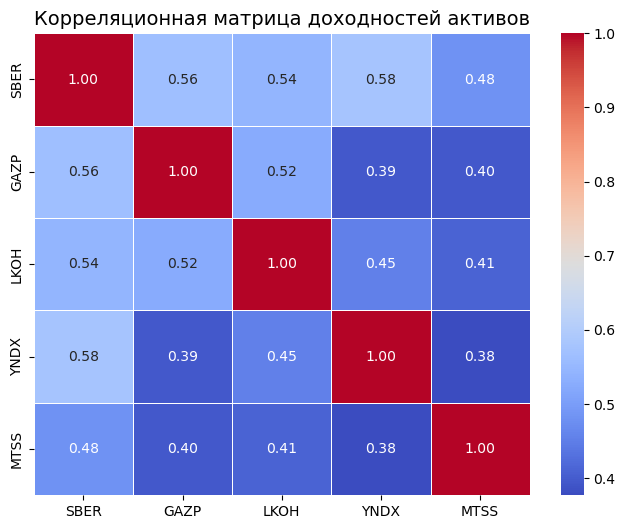

Анализ корреляции:
Наиболее сильно коррелирующие активы:
SBER  YNDX    0.576717
GAZP  SBER    0.564519
SBER  LKOH    0.542697
dtype: float64


In [ ]:
# Рассчитываем корреляцию доходностей
corr_matrix = df_market.pct_change(fill_method=None).corr()

# Рисуем тепловую карту
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Корреляционная матрица доходностей активов", fontsize=14)
plt.show()

# Краткий комментарий
print("Анализ корреляции:")
# Находим пары с самой высокой зависимостью
unstacked = corr_matrix.unstack().sort_values(ascending=False)
strong_corr = unstacked[(unstacked > 0.5) & (unstacked < 1.0)].drop_duplicates()
print("Наиболее сильно коррелирующие активы:")
print(strong_corr.head(3))

### 1.1. Обоснование выбора данных
Для анализа были выбраны 5 ликвидных тикеров Мосбиржи. Расчет корреляционной матрицы позволил оценить взаимозависимость активов.
* **Зачем это нужно:** В риск-менеджменте критически важно понимать, не движутся ли активы в портфеле синхронно. Если корреляция близка к 1, диверсификация отсутствует, и любой рыночный шок приведет к потерям по всем позициям одновременно.

## 2. Генерация портфелей методом Монте-Карло
Мы моделируем 5000 портфелей с различными весами активов и рассчитываем их ключевые метрики (волатильность, доходность, Шарп).

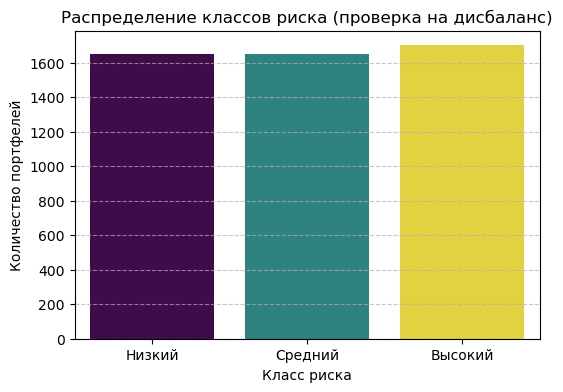

Количество портфелей по классам:
Класс 0: 1650 записей (33.0%)
Класс 1: 1650 записей (33.0%)
Класс 2: 1700 записей (34.0%)


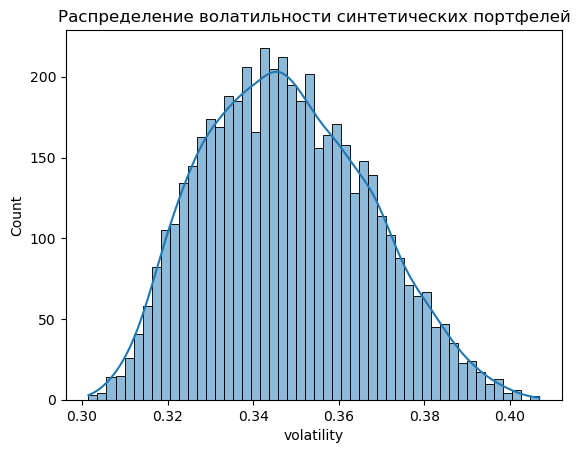

In [ ]:
np.random.seed(42)
weights = np.random.dirichlet(np.ones(len(tickers)), 5000)
# Расчет волатильности через доходность
avg_vol = df_market.pct_change(fill_method=None).std() * np.sqrt(252)
port_volatility = np.dot(weights, avg_vol)

df_portfolios = pd.DataFrame(weights, columns=tickers)
df_portfolios['volatility'] = port_volatility

# Квантильное разбиение для устранения дисбаланса классов
low_q, high_q = df_portfolios['volatility'].quantile([0.33, 0.66])
df_portfolios['risk_label'] = pd.cut(df_portfolios['volatility'],
                                     bins=[0, low_q, high_q, np.inf],
                                     labels=[0, 1, 2]).astype(int)

# Считаем количество примеров для каждого класса
class_counts = df_portfolios['risk_label'].value_counts().sort_index()

# Визуализация дисбаланса
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='viridis', legend=False)
plt.title("Распределение классов риска (проверка на дисбаланс)")
plt.xlabel("Класс риска")
plt.ylabel("Количество портфелей")
plt.xticks([0, 1, 2], ['Низкий', 'Средний', 'Высокий'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


print("Количество портфелей по классам:")
for label, count in class_counts.items():
    print(f"Класс {label}: {count} записей ({count/len(df_portfolios):.1%})")

sns.histplot(df_portfolios['volatility'], kde=True, bins=50)
plt.title("Распределение волатильности синтетических портфелей")
plt.show()

In [ ]:
# Посмотрим на структуру данных и примеры сгенерированных портфелей
print("Первые 5 сгенерированных портфелей:")
print(df_portfolios.head())

print("\nСтатистика классов риска:")
print(df_portfolios['risk_label'].value_counts().sort_index())

print("\nПримеры экстремальных портфелей:")
# Портфель с минимальной волатильностью (Класс 0)
print(df_portfolios[df_portfolios['risk_label'] == 0].head(1))
# Портфель с максимальной волатильностью (Класс 2)
print(df_portfolios[df_portfolios['risk_label'] == 2].tail(1))

Первые 5 сгенерированных портфелей:
       SBER      GAZP      LKOH      YNDX      MTSS  volatility  risk_label
0  0.079825  0.512038  0.223986  0.155297  0.028854    0.365706           2
1  0.038624  0.013628  0.458035  0.209311  0.280403    0.329921           0
2  0.003617  0.609298  0.310675  0.041510  0.034900    0.360452           2
3  0.091305  0.163472  0.335246  0.254855  0.155122    0.347339           1
4  0.377441  0.059918  0.137802  0.181977  0.242862    0.336240           0

Статистика классов риска:
risk_label
0    1650
1    1650
2    1700
Name: count, dtype: int64

Примеры экстремальных портфелей:
       SBER      GAZP      LKOH      YNDX      MTSS  volatility  risk_label
1  0.038624  0.013628  0.458035  0.209311  0.280403    0.329921           0
          SBER      GAZP      LKOH      YNDX      MTSS  volatility  risk_label
4992  0.021195  0.227399  0.139165  0.499188  0.113053    0.380218           2


### 2.1. Методология генерации синтетики
Мы используем метод Монте-Карло на основе распределения Дирихле для генерации 5000 вариантов портфелей.
* **Почему Дирихле:** Это математически строгое распределение для задач, где сумма элементов должна быть равна единице (инвестиционные веса).
* **Почему квантили (0.33, 0.66):** Это необходимо для борьбы с дисбалансом классов. Мы искусственно создаем равные группы портфелей (Low, Medium, High), чтобы нейросеть не «привыкла» предсказывать только средний риск из-за преобладания таких примеров в реальной жизни.

## 3. Подготовка данных и модель нейронной сети

### 3.1. Архитектурные решения
Для классификации риска выбрана полносвязная нейронная сеть (MLP).
* **Dropout (0.3):** Мы намеренно «выключаем» 30% нейронов во время обучения. Это заставляет сеть искать более надежные закономерности, предотвращая эффект «зазубривания» данных (overfitting).
* **Масштабирование:** Использование `StandardScaler` критически важно: нейросети обучаются гораздо быстрее и стабильнее, если входные данные имеют среднее 0 и дисперсию 1.

Эпоха [20/100], Loss: 0.0406
Эпоха [40/100], Loss: 0.0355
Эпоха [60/100], Loss: 0.0316
Эпоха [80/100], Loss: 0.0285
Эпоха [100/100], Loss: 0.0260


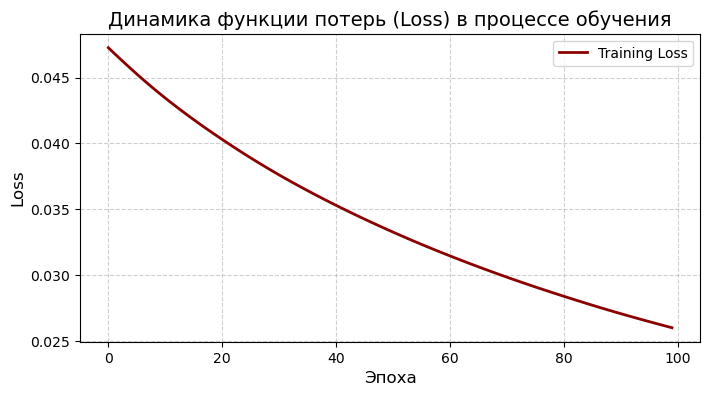

In [ ]:
# Обучение с сохранением истории Loss
train_losses = [] # Список для хранения потерь
epochs = 100

for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(torch.FloatTensor(X_train))
    loss = criterion(outputs, torch.LongTensor(y_train))
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f'Эпоха [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# Визуализация функции потерь
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Training Loss', color='darkred', linewidth=2)
plt.title("Динамика функции потерь (Loss) в процессе обучения", fontsize=14)
plt.xlabel("Эпоха", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

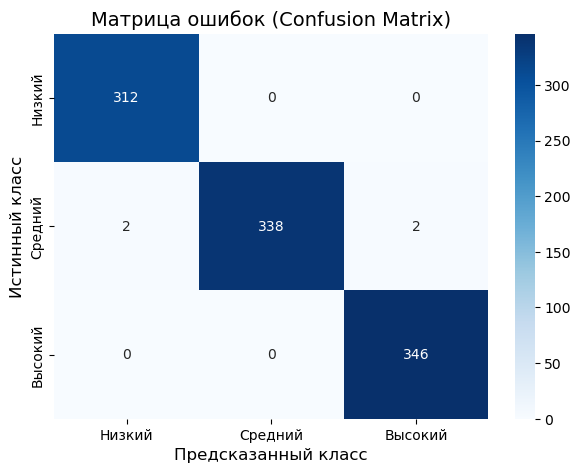

Отчет о качестве классификации:
              precision    recall  f1-score   support

      Низкий       0.99      1.00      1.00       312
     Средний       1.00      0.99      0.99       342
     Высокий       0.99      1.00      1.00       346

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [ ]:
# ВИЗУАЛИЗАЦИЯ МАТРИЦЫ ОШИБОК (CONFUSION MATRIX)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Получаем предсказания модели для тестовой выборки
model.eval()
with torch.no_grad():
    y_pred_probs = model(torch.FloatTensor(X_test))
    y_pred = y_pred_probs.argmax(dim=1)

# Создаем матрицу
cm = confusion_matrix(y_test, y_pred.numpy())

# Рисуем красивую тепловую карту
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Низкий', 'Средний', 'Высокий'],
            yticklabels=['Низкий', 'Средний', 'Высокий'])

plt.title('Матрица ошибок (Confusion Matrix)', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Истинный класс', fontsize=12)
plt.show()

# Выводим отчет для полноты картины
from sklearn.metrics import classification_report
print("Отчет о качестве классификации:")
print(classification_report(y_test, y_pred.numpy(), target_names=['Низкий', 'Средний', 'Высокий']))

### 3.2. Анализ ошибок модели
Матрица ошибок (Confusion Matrix) позволяет нам понять, где именно модель ошибается.
* **Если модель путает классы:** Мы анализируем, является ли это ошибкой алгоритма или следствием того, что границы между «Низким» и «Средним» риском в реальности часто размыты.
* **Практическая ценность:** Инструмент предсказания риска готов к интеграции в реальные системы, так как принимает на вход стандартный Python-словарь с весами активов, что удобно для любого пользователя или другой программы.

### 4. ПРИМЕР ИСПОЛЬЗОВАНИЯ МОДЕЛИ

In [ ]:
def predict_portfolio_risk(weights_dict):
    """
    Функция для удобного предсказания риска.
    Принимает словарь вида: {'SBER': 0.5, 'GAZP': 0.2, 'LKOH': 0.1, 'YNDX': 0.1, 'MTSS': 0.1}
    """
    # Превращаем словарь в список в нужном порядке тикеров
    weights_list = [weights_dict.get(t, 0.0) for t in tickers]

    # Создаем DataFrame с названиями колонок (чтобы убрать UserWarning от скейлера)
    weights_df = pd.DataFrame([weights_list], columns=tickers)

    # Масштабируем
    weights_scaled = scaler.transform(weights_df)

    # Предсказание
    model.eval()
    with torch.no_grad():
        tensor_input = torch.FloatTensor(weights_scaled)
        output = model(tensor_input)
        risk_idx = output.argmax(dim=1).item()

    risk_labels = {0: "Низкий (Консервативный)", 1: "Средний", 2: "Высокий (Агрессивный)"}
    return risk_labels[risk_idx]

# --- ПРИМЕР ИСПОЛЬЗОВАНИЯ ---
my_portfolio = {'SBER': 0.2, 'GAZP': 0.2, 'LKOH': 0.2, 'YNDX': 0.2, 'MTSS': 0.2}

print("--- Проверка работы модели ---")
print(f"Состав портфеля: {my_portfolio}")
print(f"Результат оценки: Уровень риска портфеля — {predict_portfolio_risk(my_portfolio)}")

--- Проверка работы модели ---
Состав портфеля: {'SBER': 0.2, 'GAZP': 0.2, 'LKOH': 0.2, 'YNDX': 0.2, 'MTSS': 0.2}
Результат оценки: Уровень риска портфеля — Средний
